# Part 1: Intro, and the all-important import statements

## Read this.
By reading near-surface data from the NASA [MERRA2 Reanalysis](https://gmao.gsfc.nasa.gov/reanalysis/merra-2/) product from May 31, 2021, we can create a four panel plot showing:

* the pressure of the bottom model level (near the surface)
* the modeled sea level pressure
* the calculated sea level pressure (constant $\overline{T}$)
* the calculated sea level pressure (constant $\overline\Gamma=6.5$ K km$^{-1}$)

This will also give you good practice with the approximate solutions to the hydrostatic approximation given in §4.2.

A reanalysis uses a forecast model and observations to do something like a zero-hour forecast (or analysis) for every hour retrospectively. If you want to analyze a past weather event, a reanalysis is a great place to start.

You can download data yourself [here](https://disc.gsfc.nasa.gov/datasets?project=MERRA-2) if you're interested.

These data are distributed as [netCDF](https://www.unidata.ucar.edu/software/netcdf/) files, which are the [Unidata](https://www.unidata.ucar.edu/) standard file format for gridded data. I told you that GRIB2s are stacked maps. netCDFs can be many-dimensional. So if you just want weather maps, GRIB2s are great. If you want anything else, netCDFs are more flexible. I prefer netCDFs, but that's probably reflecting my bias as a scientist rather than an operational forecaster.

## Run the cell below
See `setup_slp_extrapolation.py` if you are interested in the code.

In [20]:
# If this notebook is running in JupyterLite, install the browser Python packages it needs.
try:
    import piplite
except ImportError:
    pass
else:
    await piplite.install(['numpy', 'matplotlib', 'scipy', 'xarray'])

%run setup_slp_extrapolation.py
%matplotlib inline

## Read this.
A challenge with this assignment is that we are accustomed to thinking of equations like §4.33,
$$p(z)=p_0-\rho g z$$
as representing the pressure $p$ for some positive altitude $z$ above sea level (where $z=0$ and $p=0$).

For this assignment, instead of thinking of sea level as $z_0=0$, try to think of the ground as $z_0=0$. But what does that make $z$ for sea level? Well, if the ground is *above* sea level by some amount, that means sea level is *below* ground by that same amount, right? So $z$ will be the surface altitude multiplied by negative 1.

Also, since $z_0=0$ corresponds to the ground, then so does $p_0$; that is, $p_0$ represents the surface pressure. What, then, is $p(z)$? It's the sea level pressure!

That may be a little tricky. Try sketching it out if it's wracking your brain. __This is the biggest conceptual leap needed for this assignment.__

## Fix and test a function to calculate $p(z)$ from $p_S$ and $z$ based on constant temperature $T$.
You will also need to correct the function call so that it gives you the correct limits of integration.

In [21]:
def calc_p_constant_T(p_0, z, R_d, T, g):
    # I'll calculate scale-height for you so you can use it in your expression on the return line.
    H = R_d * T / g

    # I'm defining e here so you don't have to learn numpy.
    e = np.exp(1)

    # This line is intentionally bad, but notice how it uses e and H. Also, ** means exponentiation.
    return p_0*e**(0.0*H)

# Depending on how you corrected calc_p_constant_T,
# you may need to tweak the line below to get the limits of integration correct.
# ml_p_avg is approximately the surface pressure
# ml_z_avg is approximately the surface altitude
# Rd = 287 J/kg/K
# ml_t_avg is approximately the surface temperature
# gravity = 9.81 m/s^2
slp_const_temp_avg = calc_p_constant_T(ml_p_avg, ml_z_avg, Rd, ml_t_avg, gravity)

## Fix and test a function to calculate $p(z)$ from $p_S$ and $z$ based on constant lapse rate $\Gamma$.

In [22]:
def calc_p_constant_Gamma(p_0, z, R_d, T_0, g, Gamma):
    # I'll calculate T(z) for you so you can use it in the return line.
    T = T_0-Gamma*z

    # This line is intentionally bad, but notice how it uses T.
    return p_0*T**0.0
# Depending on how you corrected calc_p_constant_Gamma,
# you may need to tweak the line below to get the limits of integration correct.
# ml_p_avg is approximately the surface pressure
# ml_z_avg is approximately the surface altitude
# Rd = 287 J/kg/K
# ml_t_avg is approximately the surface temperature
# gravity = 9.81 m/s^2
# gamma = 6.5 K/km
slp_const_gamma_avg = calc_p_constant_Gamma(ml_p_avg, ml_z_avg, Rd, ml_t_avg, gravity, gamma)


# Part 3: Apply your calculations to real data.
We're going to be using real data *with units*. If your code above is good, things should be dimensionally consistent, and things should just work. "Hold on to your hats!"

## Take a look at the maps below before completing this next step.

The bottom two maps below should look wrong the first time you run the plotting cell. This is because I purposefully broke the sea level pressure calculation functions so that they just multiply the near-surface pressure by 1, so the only differences between the top left panel and the bottom two panels that I created are the color scales and plot ranges. Try to guess what the graphs will look like now that you have (hopefully) fixed the SLP calculators.

Did you do that? Great!

## Now run the cell below to re-plot the maps below.

Take a look and see if your results make sense. We'll talk about them in class.

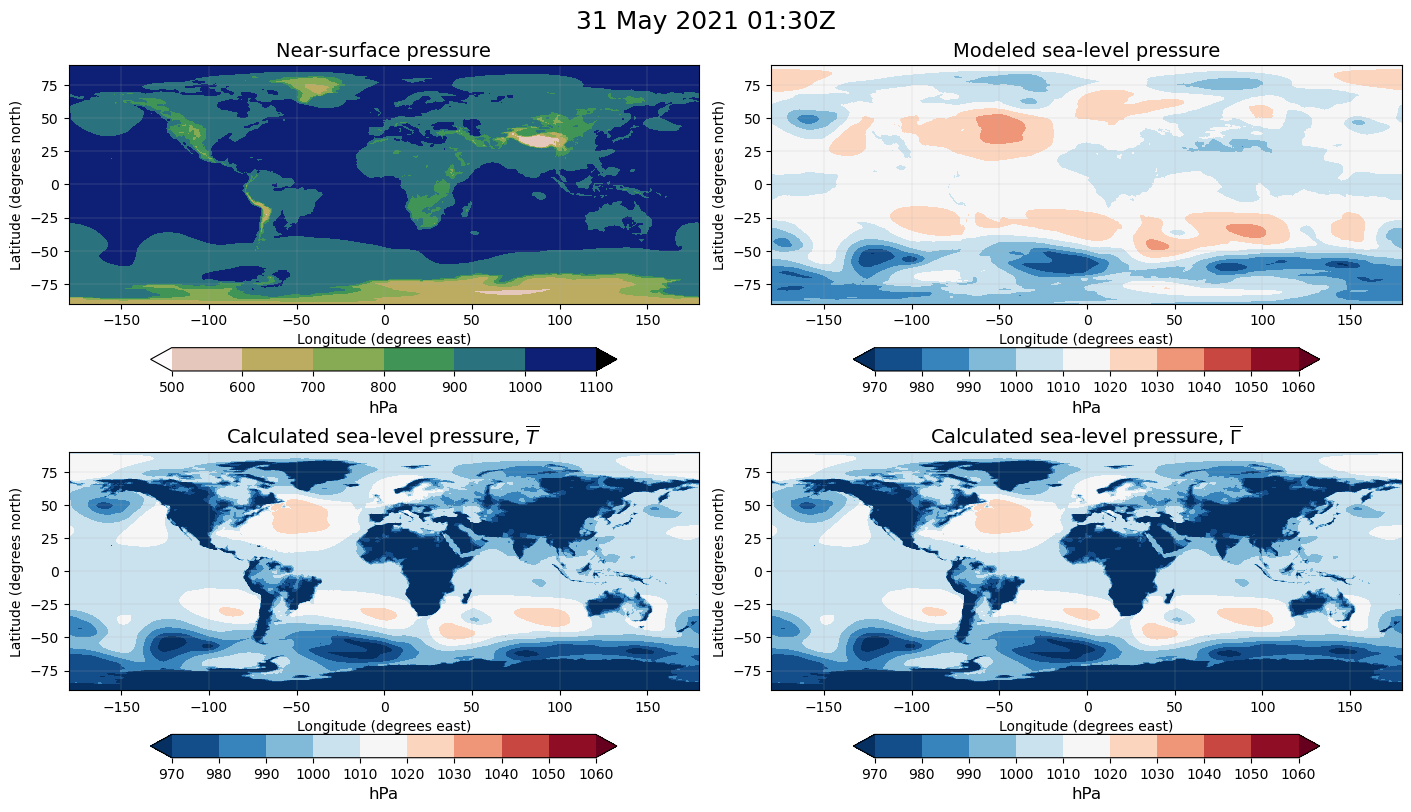

<Figure size 640x480 with 0 Axes>

In [23]:
%run -i plot_slp_extrapolation.py

## Iterate!
Take a look at your maps. Do they look realistic? Do the bottom maps look like something you could reasonably use for weather forecasting over ocean _and land_? If not, correct your functions (or your function calls) and try again.

# Part 4: Grads Do Some Extra Coding.
You will need to refer to `setup_slp_extrapolation.py` and `plot_slp_extrapolation.py`.

The calculations done above were for a daily mean, for reasons discussed by Petty. Once you have your calculations above working (and you've tested them with the plots so that you're sure they look good), repeat the steps above for the 0130Z and 1330Z data, subtract the 0130Z data from the 1330Z data, and _plot the difference_. Create a new Markdown cell (I think the default cell type is "Code", but you can change it to "Markdown" using the pulldown menu) and describe your observations in it. What are the major differences between the 0130Z and 1330Z plots? What do you think is the most likely explanation for those differences?

_Hint:_ 0130 is not nighttime everywhere, and 1330 is not daytime everywhere.

_Another Hint:_ Watch your units as you work. Be sure you are working in Pascals for your calculations and plotting in hPa.

In [24]:
# This space reserved for grad students.

# Part 5: When Satisfied, Turn This In.

1. Go to the "File" menu and download the completed notebook as an `.ipynb` file.
2. Replace \[lastname\] with your last name or surname and \[firstname] with your first name or given name.
3. Upload the file to Canvas.